# Notebook 9 – Outlier Detection

## Objective

Understand outliers, their types, detection techniques, and their impact on statistical analysis and machine learning.

### Topics Covered

1. What are Outliers?
2. Types of Outliers
3. Detecting Outliers
4. IQR Method
5. Z-Score Method
6. Box Plot
7. Scatter Plot

## 1. What are Outliers?

### Definition

An outlier is an observation that is unusually different from the other observations in a dataset.

### Example

Consider the following salaries:

50,000  
52,000  
55,000  
51,000  
53,000  
500,000

The value 500,000 is much larger than the other observations and may be an outlier.

### Causes of Outliers

Outliers can occur because of:

- Data entry errors
- Measurement errors
- Genuine unusual events
- Fraudulent activity
- Rare events
- Natural variation

### Business Example

A customer normally spends ₹1,000–₹5,000, but one transaction is ₹500,000.

This could represent:

- A genuine high-value purchase
- A data entry error
- Fraud

### AI/ML Importance

Outliers can affect:

- Mean
- Standard deviation
- Correlation
- Regression models
- Machine learning model performance

## 2. Types of Outliers

### 1. Univariate Outlier

An unusual value in a single variable.

Example:

Age = 250

### 2. Multivariate Outlier

An observation that is unusual when multiple variables are considered together.

Example:

A person has a normal age and salary individually, but the combination of age and salary is unusual.

### 3. Global Outlier

An observation that is significantly different from the entire dataset.

### 4. Contextual Outlier

A value that is unusual only in a specific context.

Example:

A temperature of 35°C may be normal in summer but unusual in winter.

### 5. Collective Outlier

A group of observations that is unusual when considered together.

## 3. Detecting Outliers

There are several methods for detecting outliers.

### Common Methods

1. Visual inspection
2. IQR method
3. Z-score method
4. Box plot
5. Scatter plot
6. Statistical tests

### Important Point

An outlier should not automatically be deleted.

First determine why the value is unusual.

If it is a valid observation, removing it may lose important information.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = [10, 12, 11, 13, 12, 14, 15, 13, 12, 100]

df = pd.DataFrame({
    "Value": data
})

print(df)
print("\nDescriptive Statistics:")
print(df.describe())

   Value
0     10
1     12
2     11
3     13
4     12
5     14
6     15
7     13
8     12
9    100

Descriptive Statistics:
            Value
count   10.000000
mean    21.200000
std     27.724037
min     10.000000
25%     12.000000
50%     12.500000
75%     13.750000
max    100.000000


## 4. IQR Method

### Definition

IQR stands for Interquartile Range.

It measures the spread of the middle 50% of the data.

### Formula

IQR = Q3 - Q1

Where:

- Q1 = First Quartile
- Q3 = Third Quartile

### Outlier Boundaries

Lower Bound:

Q1 - 1.5 × IQR

Upper Bound:

Q3 + 1.5 × IQR

Any observation outside these boundaries can be considered a potential outlier.

### Example

If:

Q1 = 10

Q3 = 20

Then:

IQR = 20 - 10 = 10

Lower Bound:

10 - 1.5(10) = -5

Upper Bound:

20 + 1.5(10) = 35

Values below -5 or above 35 are potential outliers.

In [2]:
data = np.array([10, 12, 11, 13, 12, 14, 15, 13, 12, 100])

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data < lower_bound) |
    (data > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outliers:", outliers)

Q1: 12.0
Q3: 13.75
IQR: 1.75
Lower Bound: 9.375
Upper Bound: 16.375
Outliers: [100]


## 5. Z-Score Method

### Definition

Z-score measures how many standard deviations an observation is away from the mean.

### Formula

Z = (X - μ) / σ

Where:

- X = Observation
- μ = Mean
- σ = Standard deviation

### Interpretation

A Z-score of:

- 0 → Observation equals the mean
- +1 → One standard deviation above the mean
- -1 → One standard deviation below the mean

A common rule is that observations with an absolute Z-score greater than 3 may be considered potential outliers.

### Important

The threshold depends on the problem and assumptions. A Z-score is not an automatic guarantee that a point is an error.

In [3]:
from scipy.stats import zscore

data = np.array([10, 12, 11, 13, 12, 14, 15, 13, 12, 100])

z_scores = zscore(data)

print("Z-Scores:")
print(z_scores)

outliers = data[np.abs(z_scores) > 3]

print("\nPotential Outliers:", outliers)

Z-Scores:
[-0.42583397 -0.34979219 -0.38781308 -0.3117713  -0.34979219 -0.27375041
 -0.23572952 -0.3117713  -0.34979219  2.99604612]

Potential Outliers: []


## 6. Box Plot

### Definition

A box plot is a statistical visualization used to understand the distribution of data and identify potential outliers.

### Main Components

- Minimum
- Q1
- Median
- Q3
- Maximum
- Potential outliers

### Why Use a Box Plot?

Box plots provide a quick visual way to identify:

- Central tendency
- Spread
- Skewness
- Potential outliers

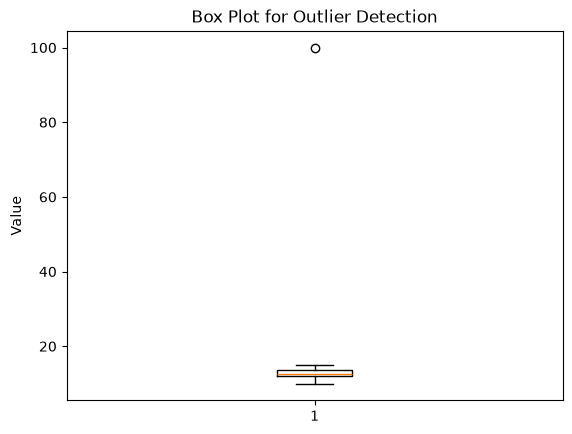

In [4]:
data = [10, 12, 11, 13, 12, 14, 15, 13, 12, 100]

plt.boxplot(data)

plt.ylabel("Value")
plt.title("Box Plot for Outlier Detection")

plt.show()

## 7. Scatter Plot

### Definition

A scatter plot displays the relationship between two numerical variables.

It can help identify unusual observations in a multivariate dataset.

### Example

Suppose we analyze:

- Advertising expenditure
- Sales

Most observations may follow a general pattern, while one observation may be far away from the others.

That observation could be a potential outlier.

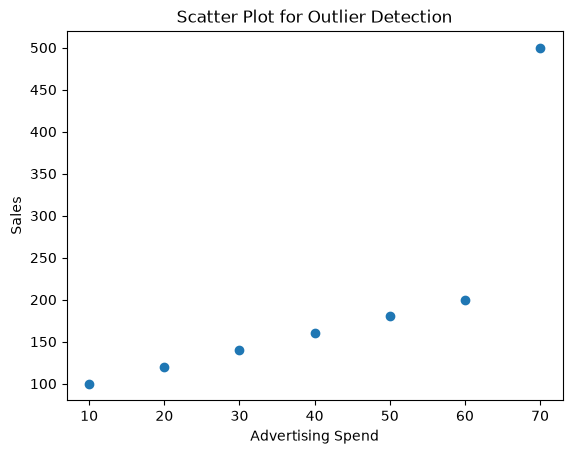

In [5]:
advertising = [10, 20, 30, 40, 50, 60, 70]
sales = [100, 120, 140, 160, 180, 200, 500]

plt.scatter(advertising, sales)

plt.xlabel("Advertising Spend")
plt.ylabel("Sales")
plt.title("Scatter Plot for Outlier Detection")

plt.show()

# AI/ML Applications

Outlier detection is important in:

- Data preprocessing
- Fraud detection
- Anomaly detection
- Data quality checks
- Feature engineering
- Model improvement

### Example

In a fraud detection system, an unusually large transaction may be flagged for further investigation.

The system should not automatically assume that every unusual transaction is fraudulent.

# Business Applications

Outlier detection is useful in:

- Fraud detection
- Financial transactions
- Customer spending analysis
- Manufacturing quality control
- Network monitoring
- Sales analysis
- Employee performance analysis

### Example

If most customers spend ₹500–₹5,000 but one transaction is ₹500,000, the company should investigate the transaction.

It could be:

- A genuine purchase
- A data error
- Fraud

# Outliers in Machine Learning

Outliers can affect machine learning models in different ways.

### Linear Regression

Outliers can strongly influence the regression line.

### K-Means Clustering

Extreme observations can influence cluster centers.

### K-Nearest Neighbors

Outliers can affect distances between observations.

### Decision Trees

Decision trees are generally less sensitive to outliers than distance- or mean-based methods.

### Neural Networks

Outliers can sometimes make training less stable, especially when input features have extreme values.

### Important

The correct treatment depends on:

- Model
- Dataset
- Cause of the outlier
- Business context

# Final Summary

In this notebook, we learned:

1. What are Outliers?
2. Types of Outliers
3. Detecting Outliers
4. IQR Method
5. Z-Score Method
6. Box Plot
7. Scatter Plot

## Key Takeaways

- Outliers are observations that differ significantly from the rest of the data.
- Outliers can occur because of errors or genuine unusual events.
- IQR is based on quartiles.
- Z-score measures distance from the mean in standard deviations.
- Box plots provide a visual way to identify potential outliers.
- Scatter plots help identify unusual observations across two variables.
- Outliers should be investigated before removing them.